In [1]:
!pip install kumoai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.4/404.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.4/95.4 kB 8.0 MB/s eta 0:00:00


In [2]:
!gcloud auth application-default login

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fapplicationdefaultauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=TJPxWwtRrsbkKaPL544Xg3JZ6cbUrZ&prompt=consent&token_usage=remote&access_type=offline&code_challenge=5MMAGfn1wpiKspXota6IiHbNHpRbtOxDHezCJWmVjr0&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0AdkVLPw4BIzvO7-4GOEA98GkO2Y06CaN-QpHn3Fy7sgOb-oG3O8ycw_lH-ixWLq4PY42oA

Credentials saved to file: [/content/.config/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).
Ca

In [3]:
import os
import kumoai.experimental.rfm as rfm, os
import pandas as pd

from google.cloud import bigquery

In [5]:
KUMO_API_KEY = os.environ.get("KUMO_API_KEY")
rfm.init(api_key=KUMO_API_KEY)

INFO:kumoai:Initialized Kumo SDK v2.22.0 against deployment 'https://kumorfm.ai/api'


In [45]:
client = bigquery.Client(project="diesel-charge-465712-f8")

concept_df = client.query("select * from `diesel-charge-465712-f8.encode_dataset.CONCEPT`").to_dataframe()
concept_ancestor_df = client.query("select * from `diesel-charge-465712-f8.encode_dataset.CONCEPT_ANCESTOR`").to_dataframe()
concept_relationship_df = client.query("select * from `diesel-charge-465712-f8.encode_dataset.CONCEPT_RELATIONSHIP`").to_dataframe()
device_exposure_df = client.query("select * from `diesel-charge-465712-f8.encode_dataset.DEVICE_EXPOSURE`").to_dataframe()
measurement_df = client.query("select * from `diesel-charge-465712-f8.encode_dataset.MEASUREMENT`").to_dataframe()
observation_df = client.query("select * from `diesel-charge-465712-f8.encode_dataset.OBSERVATION`").to_dataframe()
observation_period_df = client.query("select * from `diesel-charge-465712-f8.encode_dataset.OBSERVATION_PERIOD`").to_dataframe()
person_df = client.query("select * from `diesel-charge-465712-f8.encode_dataset.PERSON`").to_dataframe()
procedure_occurrence_df = client.query("select * from `diesel-charge-465712-f8.encode_dataset.PROCEDURE_OCCURRENCE`").to_dataframe()
visit_occurrence_df = client.query("select * from `diesel-charge-465712-f8.encode_dataset.VISIT_OCCURRENCE`").to_dataframe()
vocabulary_df = client.query("select * from `diesel-charge-465712-f8.encode_dataset.VOCABULARY`").to_dataframe()

/usr/local/lib/python3.12/dist-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [46]:
len(concept_df) + len(concept_ancestor_df) + len(concept_relationship_df) + len(device_exposure_df) + len(measurement_df) + len(observation_df) + len(observation_period_df) + len(person_df) + len(procedure_occurrence_df) + len(visit_occurrence_df) + len(vocabulary_df)

1141573

In [47]:
tables_dict = {
    "concept": concept_df,
    "concept_ancestor": concept_ancestor_df,
    "concept_relationship": concept_relationship_df,
    "device_exposure": device_exposure_df,
    "measurement": measurement_df,
    "observation": observation_df,
    "observation_period": observation_period_df,
    "person": person_df,
    "procedure_occurrence": procedure_occurrence_df,
    "visit_occurrence": visit_occurrence_df,
    'vocabulary': vocabulary_df
}

In [48]:
def preprocess_tables_dict(tables_dict):
    for table_name, df in tables_dict.items():
      dbdate_columns = df.dtypes[df.dtypes == 'dbdate'].index.tolist()
      dbtime_columns = df.dtypes[df.dtypes == 'dbtime'].index.tolist()
      for col in dbdate_columns:
        df[col] = pd.to_datetime(df[col])

      for col in dbtime_columns:
        df[col] = pd.to_datetime(df[col], format='%H:%M:%S').dt.time

    return tables_dict

In [49]:
def transform_to_rfm_table(tables_dict):
  result = {}
  for table_name, df in tables_dict.items():
    rfm_table = rfm.LocalTable(
      df = df,
      name = table_name
    ).infer_metadata()
    result[table_name] = rfm_table
  return result

In [50]:
tables_dict = preprocess_tables_dict(tables_dict)

In [51]:
tables = transform_to_rfm_table(tables_dict)

/usr/local/lib/python3.12/dist-packages/kumoai/rfm/infer/pkey.py:124: UserWarning: Found multiple potential primary keys in table 'concept': []. Please specify the primary key for this table manually.
  warnings.warn(f"Found multiple potential primary keys in table "


Inferred time column `valid_start_date` for table `concept`

Inferred time column `valid_start_date` for table `concept_relationship`

Inferred primary key `device_exposure_id` and time column `device_exposure_start_date` for table `device_exposure`

Inferred primary key `measurement_id` and time column `measurement_date` for table `measurement`

...

Inferred primary key `observation_period_id` and time column `observation_period_start_date` for table `observation_period`

Inferred primary key `person_id` and time column `birth_datetime` for table `person`

Inferred primary key `procedure_occurrence_id` and time column `procedure_date` for table `procedure_occurrence`

Inferred primary key `visit_occurrence_id` and time column `visit_start_date` for table `visit_occurrence`

Inferred primary key `vocabulary_id` and time column `vocabulary_version` for table `vocabulary`

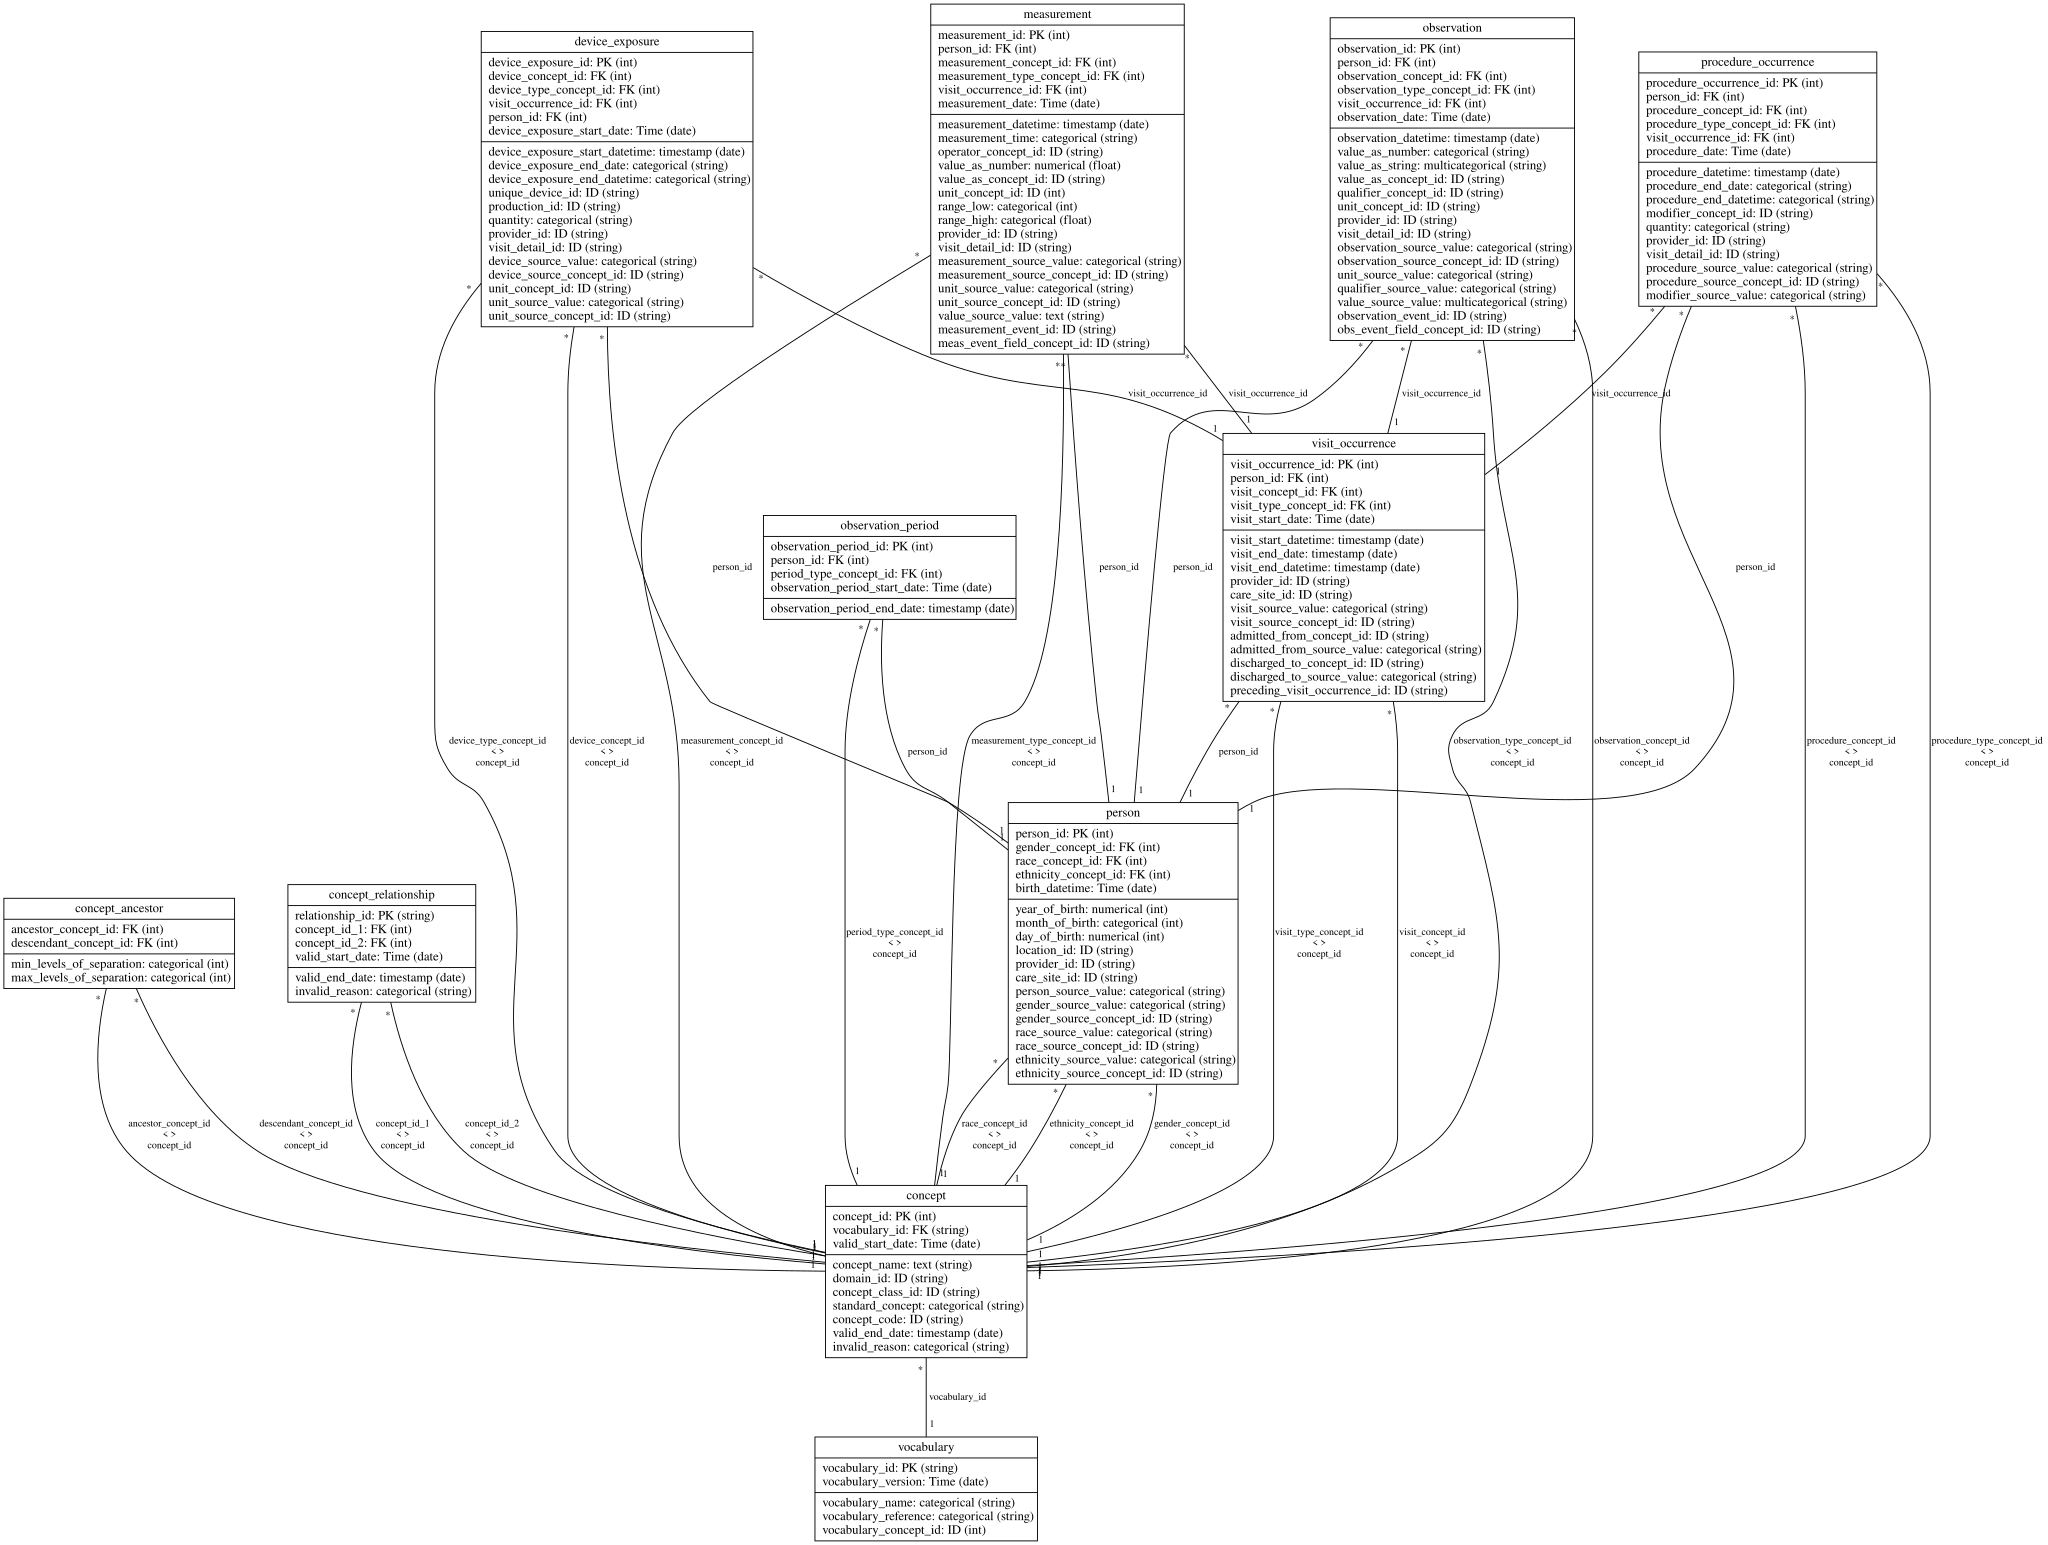

In [60]:
graph = rfm.LocalGraph(tables=tables.values())

tables['concept'].primary_key = 'concept_id'
tables['concept_relationship'].primary_key = 'relationship_id'

graph.link(src_table='measurement', fkey='person_id', dst_table='person')
graph.link(src_table='measurement', fkey='measurement_concept_id', dst_table='concept')
graph.link(src_table='measurement', fkey='measurement_type_concept_id', dst_table='concept')
graph.link(src_table='measurement', fkey='visit_occurrence_id', dst_table='visit_occurrence')

graph.link(src_table='observation', fkey='person_id', dst_table='person')
graph.link(src_table='observation', fkey='observation_concept_id', dst_table='concept')
graph.link(src_table='observation', fkey='observation_type_concept_id', dst_table='concept')
graph.link(src_table='observation', fkey='visit_occurrence_id', dst_table='visit_occurrence')

graph.link(src_table='observation_period', fkey='person_id', dst_table='person')
graph.link(src_table='observation_period', fkey='period_type_concept_id', dst_table='concept')

graph.link(src_table='procedure_occurrence', fkey='person_id', dst_table='person')
graph.link(src_table='procedure_occurrence', fkey='procedure_concept_id', dst_table='concept')
graph.link(src_table='procedure_occurrence', fkey='procedure_type_concept_id', dst_table='concept')
graph.link(src_table='procedure_occurrence', fkey='visit_occurrence_id', dst_table='visit_occurrence')

graph.link(src_table='visit_occurrence', fkey='person_id', dst_table='person')
graph.link(src_table='visit_occurrence', fkey='visit_concept_id', dst_table='concept')
graph.link(src_table='visit_occurrence', fkey='visit_type_concept_id', dst_table='concept')

graph.link(src_table='device_exposure', fkey='device_concept_id', dst_table='concept')
graph.link(src_table='device_exposure', fkey='device_type_concept_id', dst_table='concept')
graph.link(src_table='device_exposure', fkey='visit_occurrence_id', dst_table='visit_occurrence')

graph.link(src_table='person', fkey='gender_concept_id', dst_table='concept')
graph.link(src_table='person', fkey='race_concept_id', dst_table='concept')
graph.link(src_table='person', fkey='ethnicity_concept_id', dst_table='concept')

graph.link(src_table='concept', fkey='vocabulary_id', dst_table='vocabulary')

graph.link(src_table='concept_ancestor', fkey='ancestor_concept_id', dst_table='concept')
graph.link(src_table='concept_ancestor', fkey='descendant_concept_id', dst_table='concept')

graph.link(src_table='concept_relationship', fkey='concept_id_1', dst_table='concept')
graph.link(src_table='concept_relationship', fkey='concept_id_2', dst_table='concept')

graph.link(src_table='device_exposure', fkey='person_id', dst_table='person')

graph.visualize()

In [61]:
model = rfm.KumoRFM(graph=graph)

Output()

In [66]:
query = """
PREDICT measurement.value_as_number
FOR EACH measurement.measurement_id
"""

patient_ids = tables_dict['measurement']['measurement_id'].dropna().head(1000).tolist()

with model.batch_mode(batch_size="max", num_retries=1):
    try:
        df = model.predict(query, indices=patient_ids)
        display(df.head())
    except Exception as e:
        print(f"Error: {e}")

Output()

,ENTITY,ANCHOR_TIMESTAMP,TARGET_PRED
0,716809,2073-09-10,138.000000
1,716770,2073-09-10,182.000000
2,716759,2073-09-10,190.000000
3,716732,2073-09-10,168.072250
4,716752,2073-09-10,154.617126


In [67]:
metrics = model.evaluate(
    query,
    metrics=['mae', 'mape', 'mse', 'rmse', 'smape', 'r2']
)

metrics

Output()

,metric,value
0,mae,153.425690
1,mape,106220.992188
2,mse,268328.406250
3,r2,0.300431
4,rmse,518.004272
5,smape,0.664570
